# K-fold SCVI — per-train-run geom-distance vs val LMI

For every K-fold split (built by `2026-04-27_build_kfold_splits.py`) the
compute script trains **one SCVI per training run** (8 per fold), embeds the
fold's ~80k-cell val pool with each model, and runs `latentmi` (seed 42)
against one-hot `author_day`. Each training run carries a pre-computed
geomloss energy distance to the val pool (encoded in the source filename).

8-fold CV across the 16 `author_experimental_id`s: each fold holds 8 IDs (50%)
out for validation and trains on the remaining 8. Val sets are independently
sampled per fold so overlap between folds is allowed.

This notebook reads each `summary.json` produced by
`2026-04-27_compute_kfold_scvi_lmi.py` directly, so partial results show up
as soon as individual jobs finish (no need to wait for the consolidated CSV).
It writes a single combined PNG (`kfold_scvi_lmi.png`) with one subplot per
fold of the 8-point `(edist, lmi)` scatter. SCVI train/val ELBO curves are
plotted inline only (read from each job's `training_history.csv`) and are
not saved to `final_results/`.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ANALYSIS_DIR = Path('/home/igor/igor_repos/scaling_laws/Scaling-up-measurement-noise-scaling-laws/analysis')
FINAL_RESULTS_DIR = ANALYSIS_DIR / 'final_results'
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SCVI_OUT_DIR = Path('/home/igor/igor_repos/scaling_laws/data_local/other/batch_effects/kfold/scvi')
CSV_PATH = FINAL_RESULTS_DIR / 'kfold_scvi_lmi.csv'

FIG_DPI = 300

summary_paths = sorted(SCVI_OUT_DIR.glob('*-fold/*/summary.json'))
print(f'Found {len(summary_paths)} summary.json files under {SCVI_OUT_DIR}')

rows = []
for p in summary_paths:
    d = json.loads(p.read_text())
    if d.get('lmi') is None:
        continue
    rows.append({
        'fold': d['fold'],
        'run_id': d['run_id'],
        'val_ids': ','.join(d.get('val_ids', [])),
        'edist_train_val': d['edist_train_val'],
        'lmi': d['lmi'],
        'lmi_seed': d['lmi_seed'],
        'n_train_cells': d.get('n_train_cells'),
        'n_val_cells': d.get('n_val_cells'),
        'scvi_train_seconds': d.get('scvi_train_seconds'),
    })

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit(
        f'No completed jobs found under {SCVI_OUT_DIR}. '
        f'Run analysis/2026-04-27_compute_kfold_scvi_lmi.py first.'
    )
df = df.sort_values(['fold', 'edist_train_val']).reset_index(drop=True)
df.to_csv(CSV_PATH, index=False)
print(f'Wrote {len(df)} rows to {CSV_PATH}')
df

Found 64 summary.json files under /home/igor/igor_repos/scaling_laws/data_local/other/batch_effects/kfold/scvi
Wrote 64 rows to /home/igor/igor_repos/scaling_laws/Scaling-up-measurement-noise-scaling-laws/analysis/final_results/kfold_scvi_lmi.csv


,fold,run_id,val_ids,edist_train_val,lmi,lmi_seed,n_train_cells,n_val_cells,scvi_train_seconds
0,1-fold,run_14,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",0.7961,2.035872,42,10000,80000,166.654624
1,1-fold,run_26,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.1029,1.974775,42,10000,80000,164.978017
2,1-fold,run_20,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.2324,1.996421,42,10000,80000,164.361819
3,1-fold,run_22,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.2638,1.965257,42,10000,80000,164.224468
4,1-fold,run_21,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.4979,2.005583,42,10000,80000,176.667264
...,...,...,...,...,...,...,...,...,...
59,8-fold,run_13,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",0.9821,1.553028,42,10000,80000,159.575669
60,8-fold,run_14,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",1.1279,1.554950,42,10000,80000,158.503483
61,8-fold,run_16,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",2.0598,1.574077,42,10000,80000,160.965130
62,8-fold,run_17,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",3.8119,1.589389,42,10000,80000,160.847062


Saved /home/igor/igor_repos/scaling_laws/Scaling-up-measurement-noise-scaling-laws/analysis/final_results/kfold_scvi_lmi.png


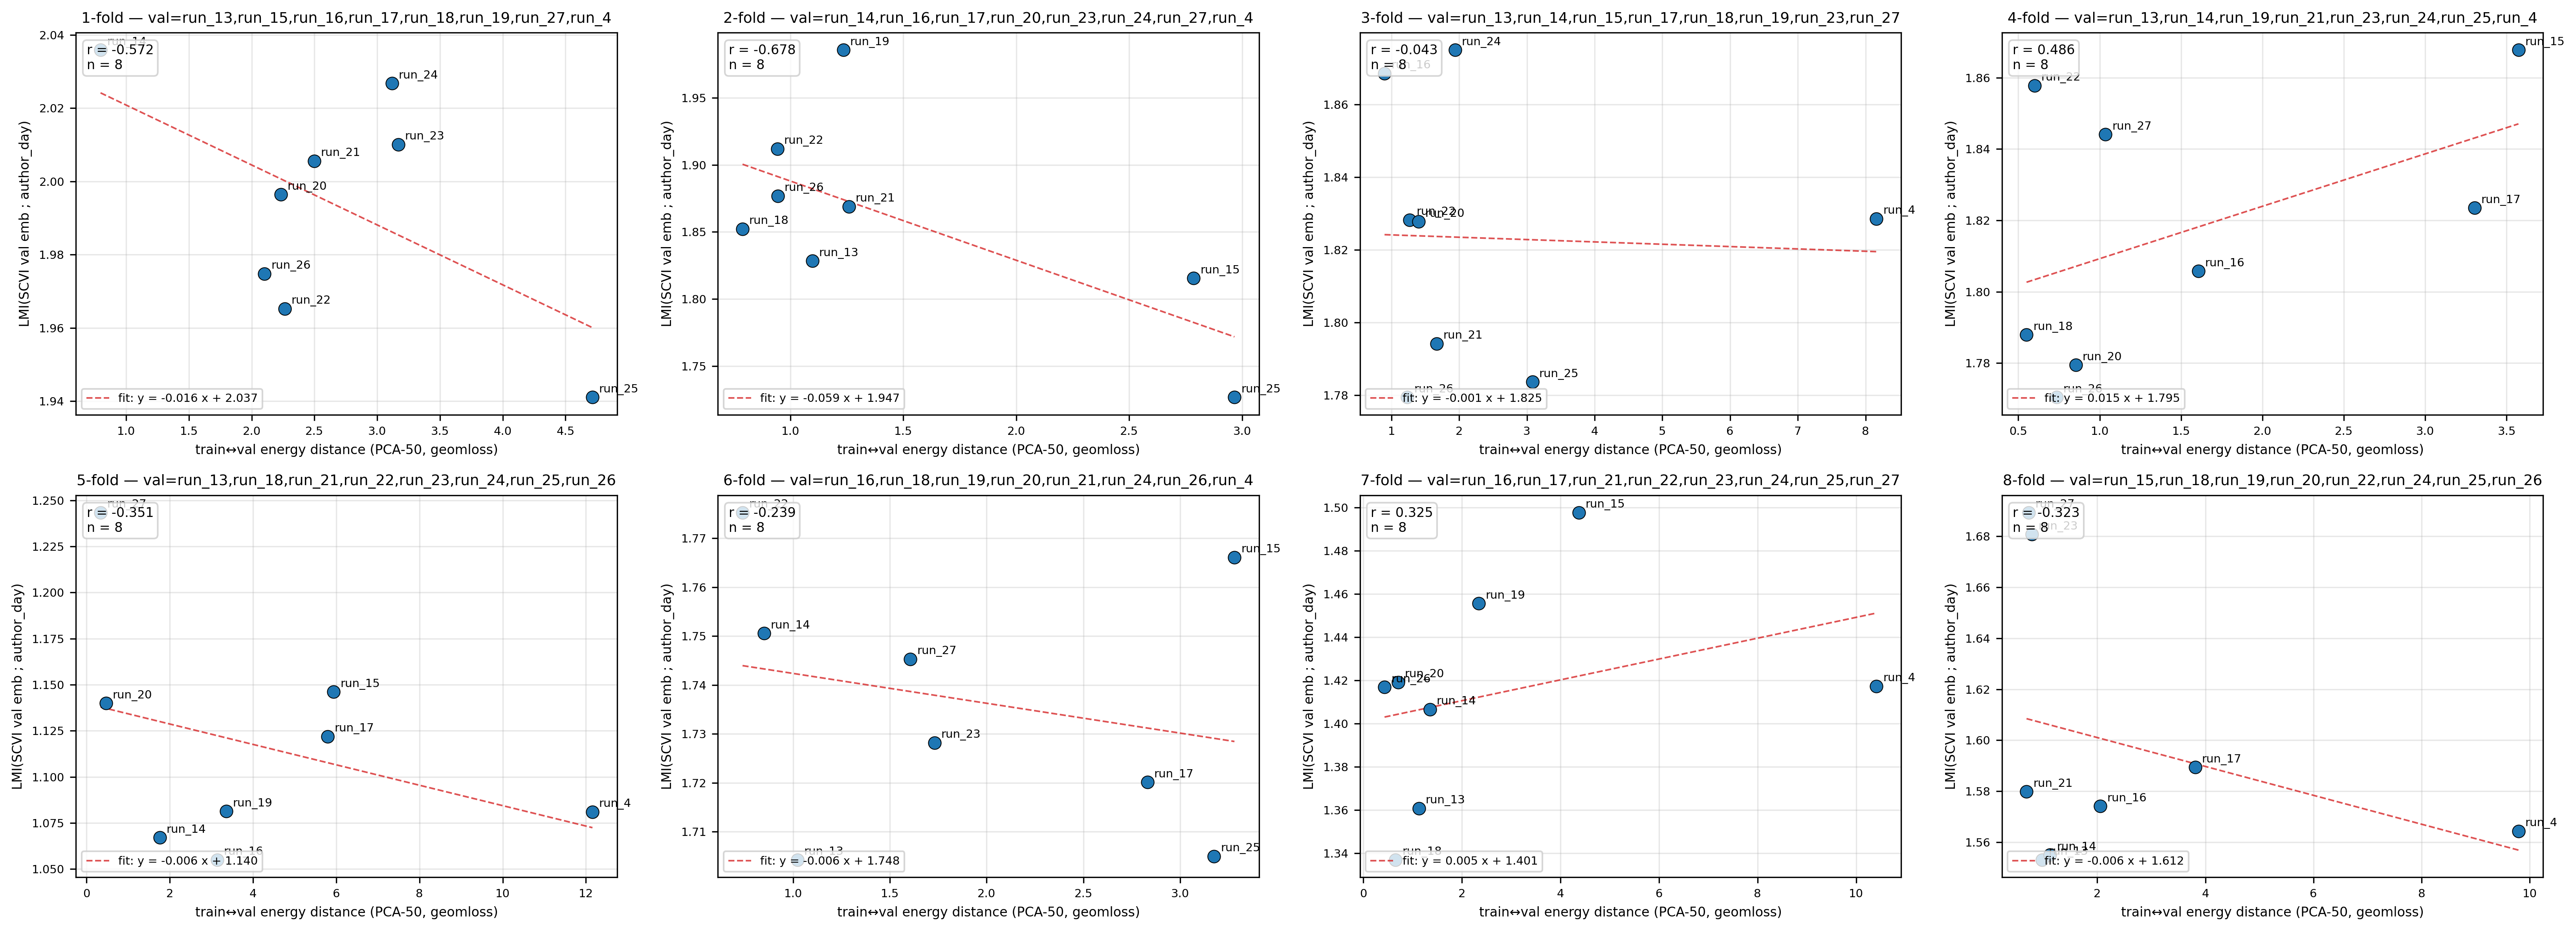

In [2]:
folds_sorted = sorted(df['fold'].unique(), key=lambda s: int(s.split('-')[0]))
n_folds = len(folds_sorted)
n_cols = min(4, n_folds)
n_rows = int(np.ceil(n_folds / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                         figsize=(5.5 * n_cols, 4.0 * n_rows),
                         dpi=FIG_DPI, squeeze=False)
axes_flat = axes.ravel()

for ax in axes_flat:
    ax.set_visible(False)

for ax, fold in zip(axes_flat, folds_sorted):
    ax.set_visible(True)
    sub = df[df['fold'] == fold].sort_values('edist_train_val').reset_index(drop=True)
    val_ids = sub['val_ids'].iloc[0]

    x = sub['edist_train_val'].to_numpy(dtype=float)
    y = sub['lmi'].to_numpy(dtype=float)

    ax.scatter(x, y, s=60, c='C0', edgecolors='k', linewidths=0.5, zorder=3)
    for run_id, xi, yi in zip(sub['run_id'], x, y):
        ax.annotate(run_id, xy=(xi, yi), xytext=(4, 3),
                    textcoords='offset points', fontsize=7)

    if len(x) >= 2 and np.ptp(x) > 0:
        slope, intercept = np.polyfit(x, y, deg=1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, slope * xs + intercept, color='C3', linestyle='--',
                linewidth=1.0, alpha=0.8, zorder=2,
                label=f'fit: y = {slope:.3f} x + {intercept:.3f}')
        r = float(np.corrcoef(x, y)[0, 1])
        ax.text(0.02, 0.97, f'r = {r:.3f}\nn = {len(x)}',
                transform=ax.transAxes, va='top', ha='left',
                fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8,
                          edgecolor='0.8'))
        ax.legend(loc='lower left', fontsize=7, frameon=True)

    ax.set_xlabel('train↔val energy distance (PCA-50, geomloss)', fontsize=8)
    ax.set_ylabel('LMI(SCVI val emb ; author_day)', fontsize=8)
    ax.set_title(f'{fold} — val={val_ids}', fontsize=9)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.3)

fig.tight_layout()
out_png = FINAL_RESULTS_DIR / 'kfold_scvi_lmi.png'
fig.savefig(out_png, dpi=FIG_DPI, bbox_inches='tight')
print(f'Saved {out_png}')
plt.show()
plt.close(fig)

## SCVI training curves

One small-multiples figure per fold: each subplot is a single training run
from that fold, showing `train_loss` and `val_loss` (per-epoch ELBO) versus
epoch, read from each job's `training_history.csv` (3 columns:
`epoch, train_loss, val_loss`). Subplots are ordered by `edist_train_val` so
the leftmost / topmost runs are the closest to the val pool. Displayed
inline only — not saved to `final_results/`.

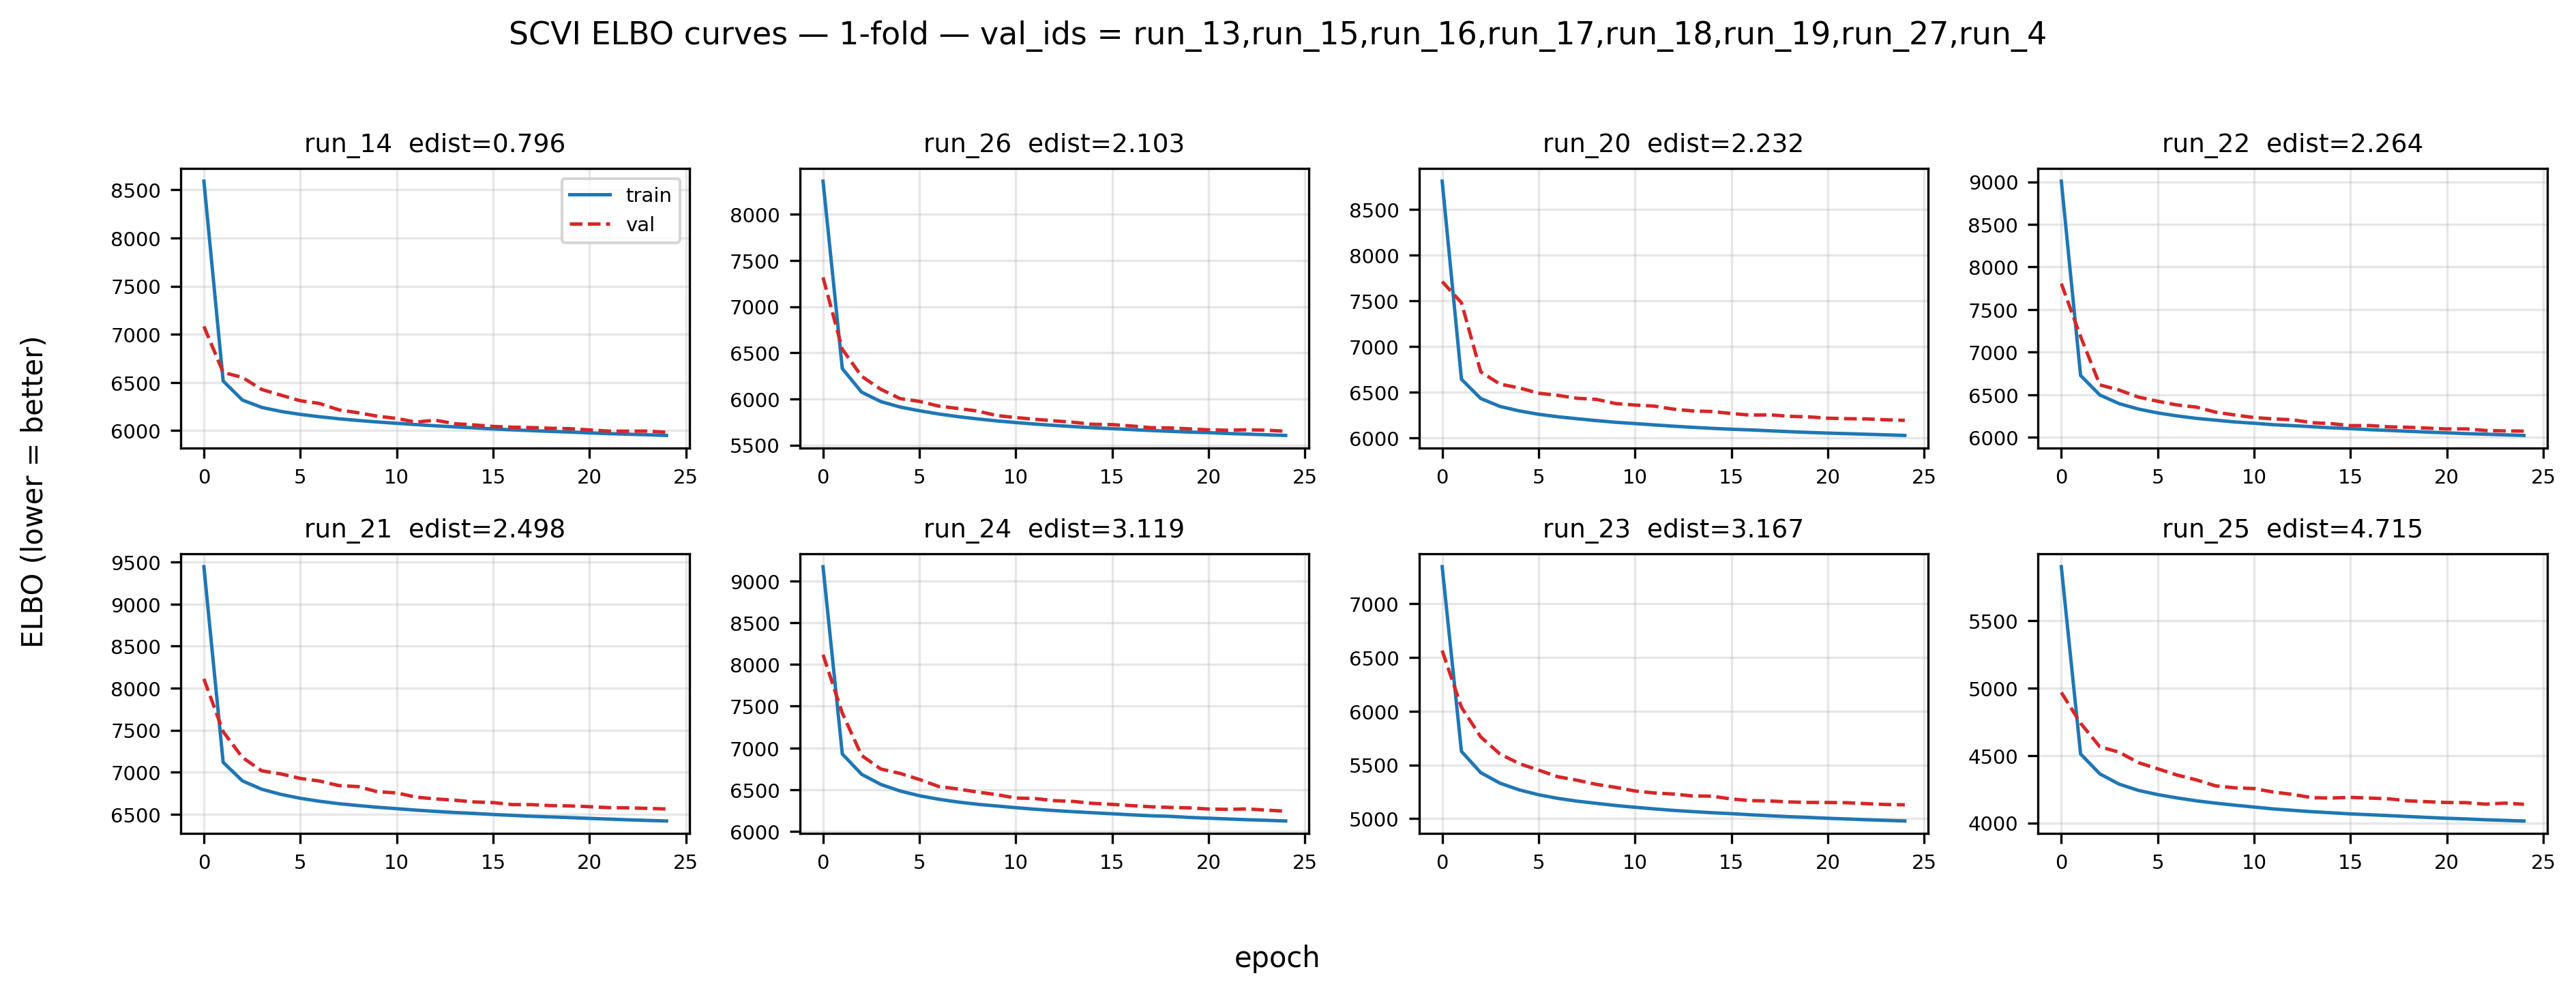

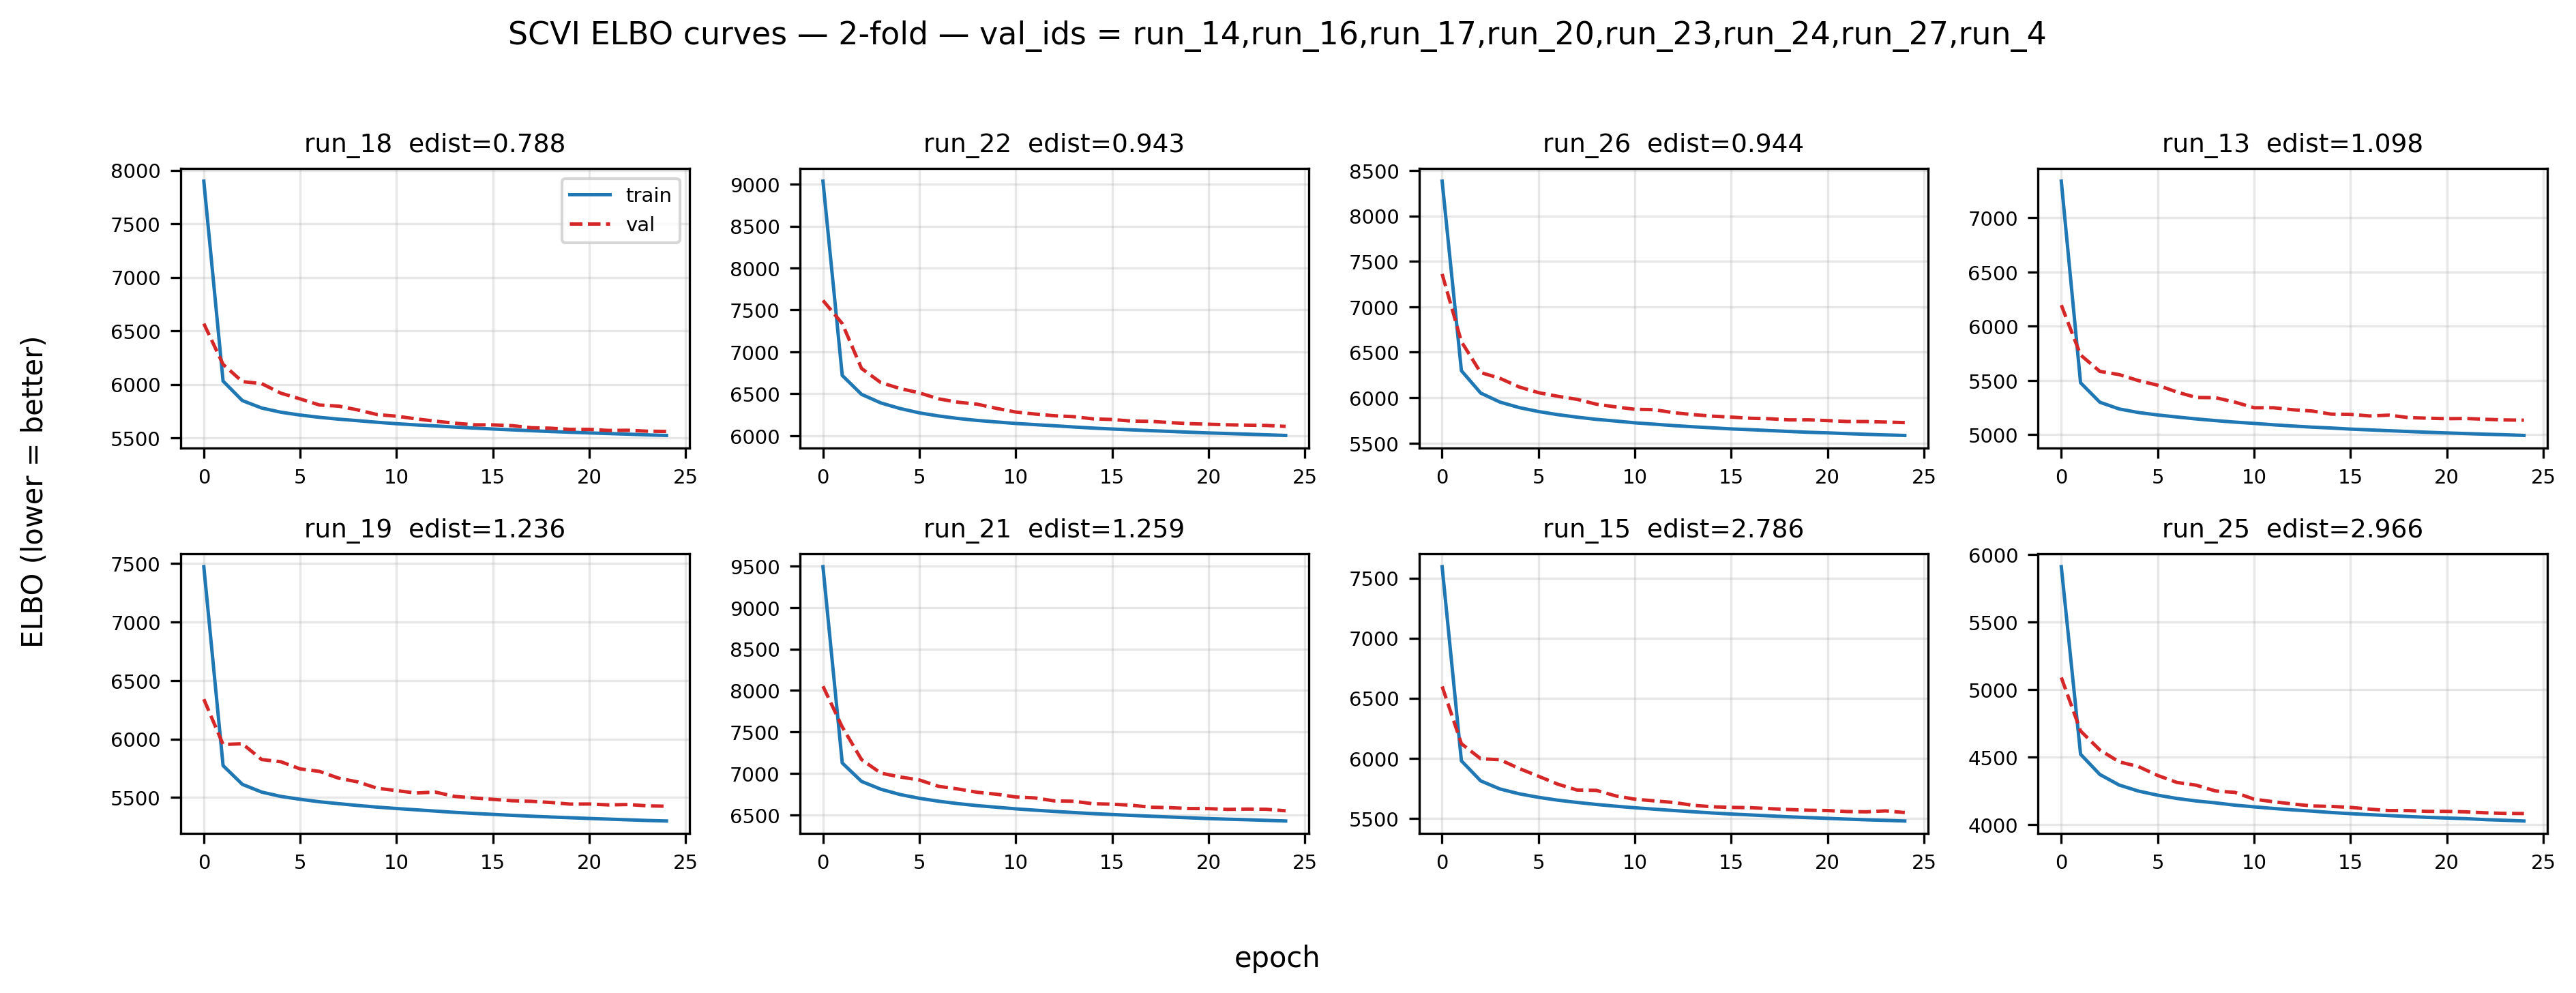

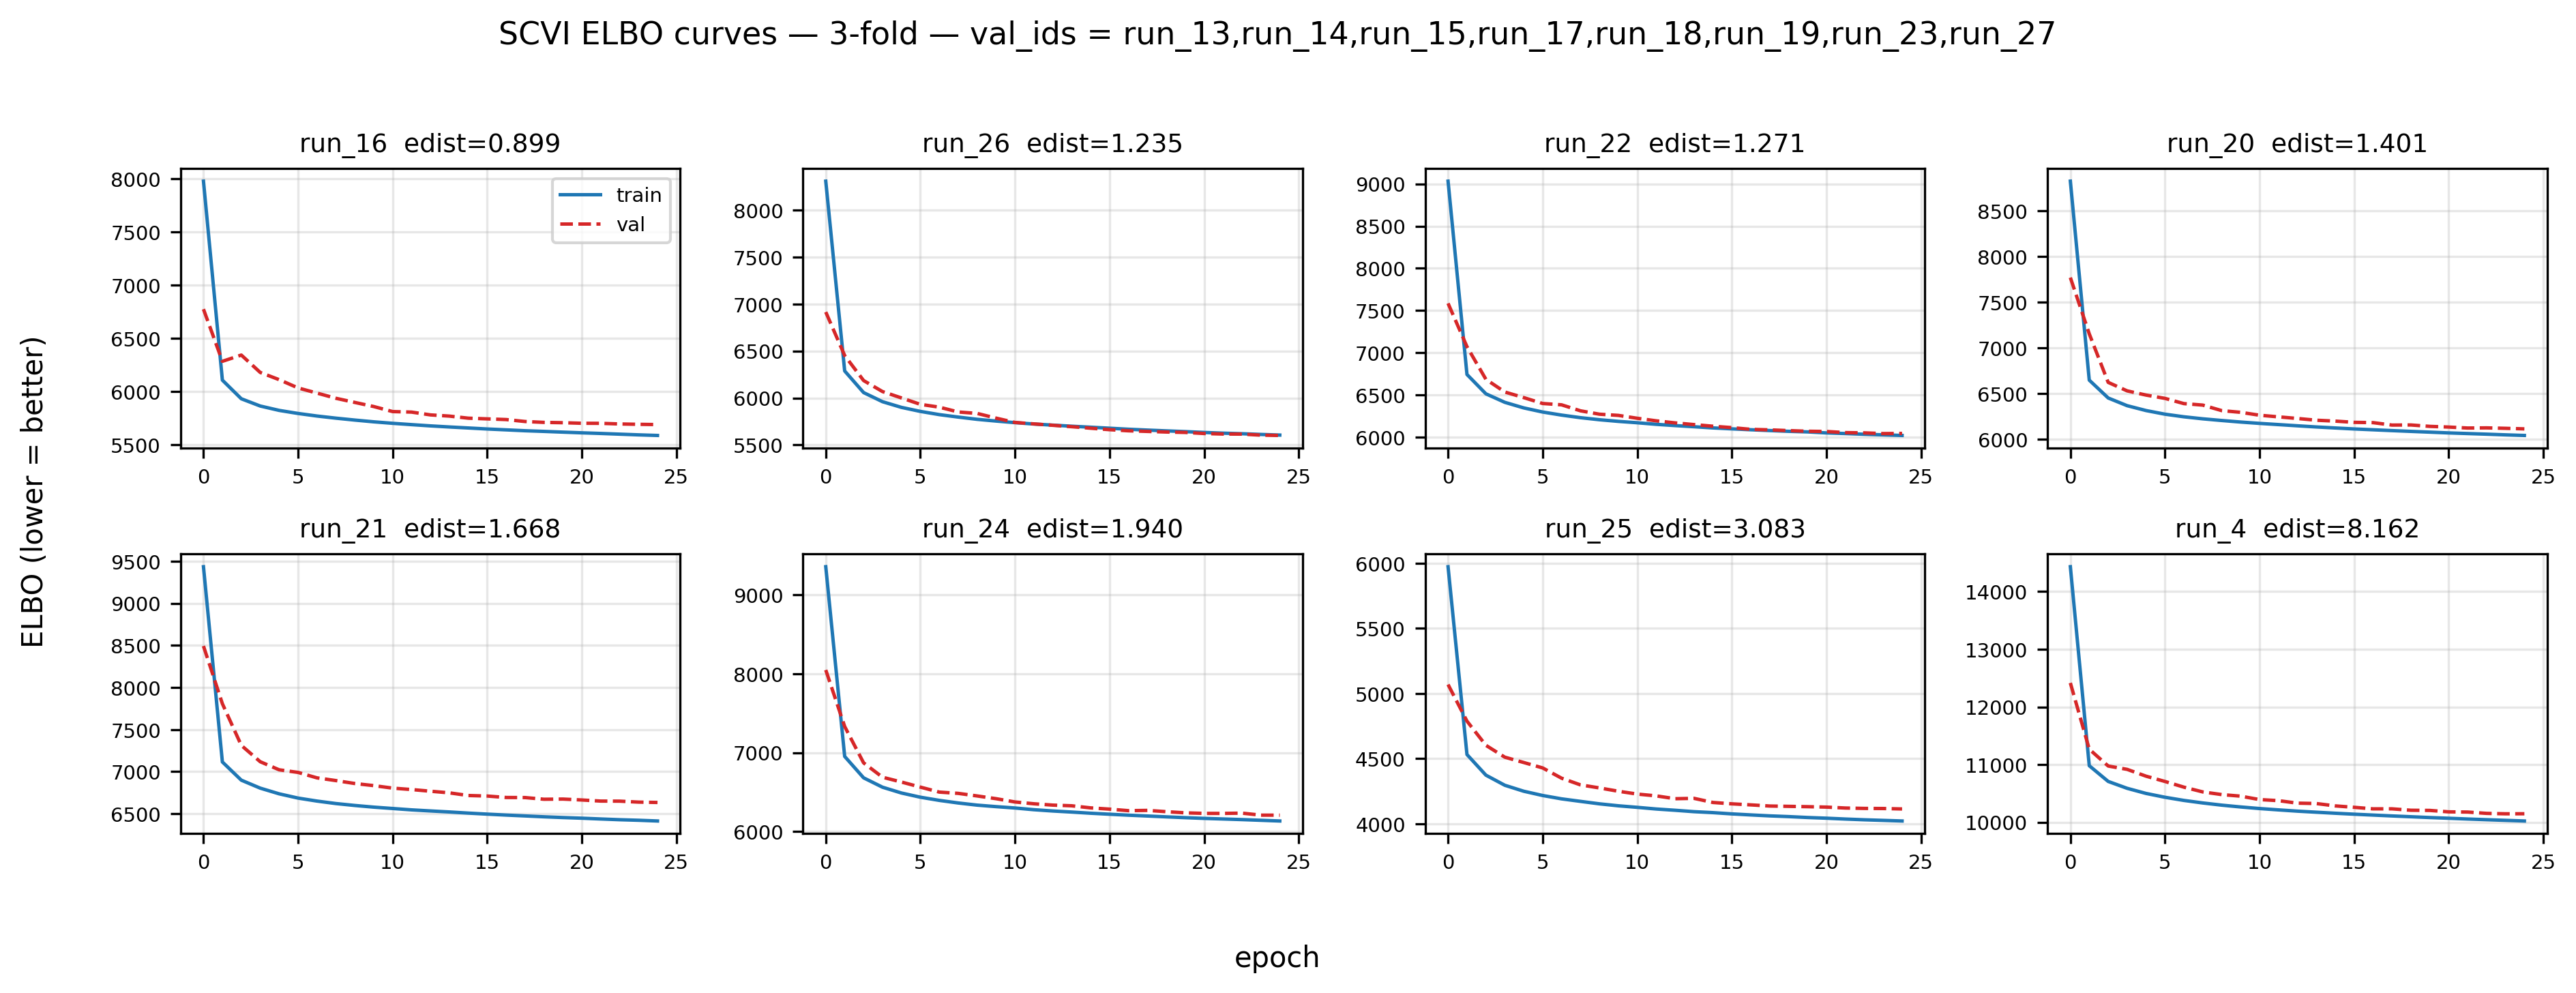

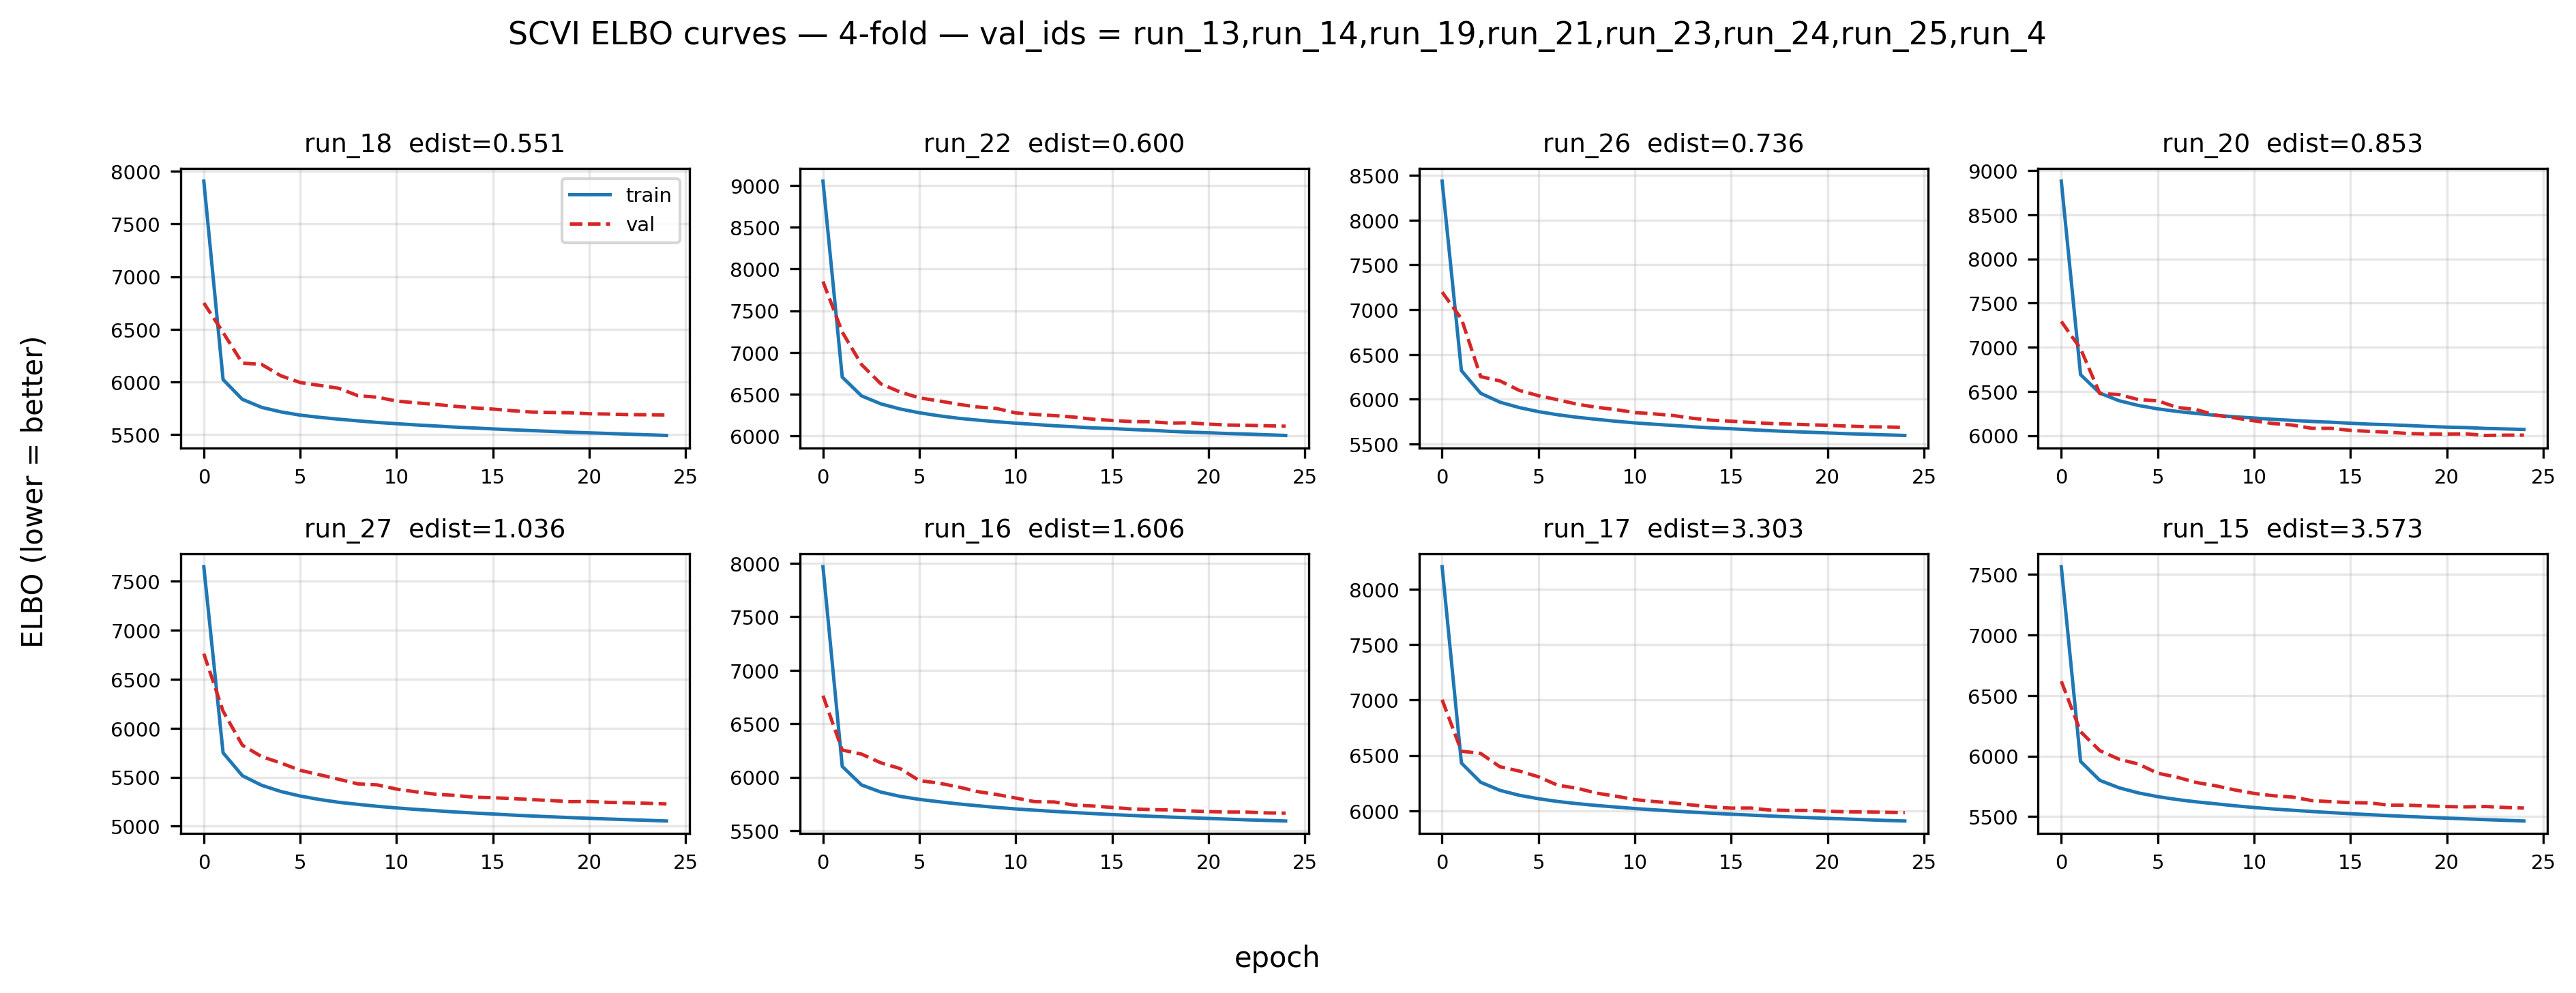

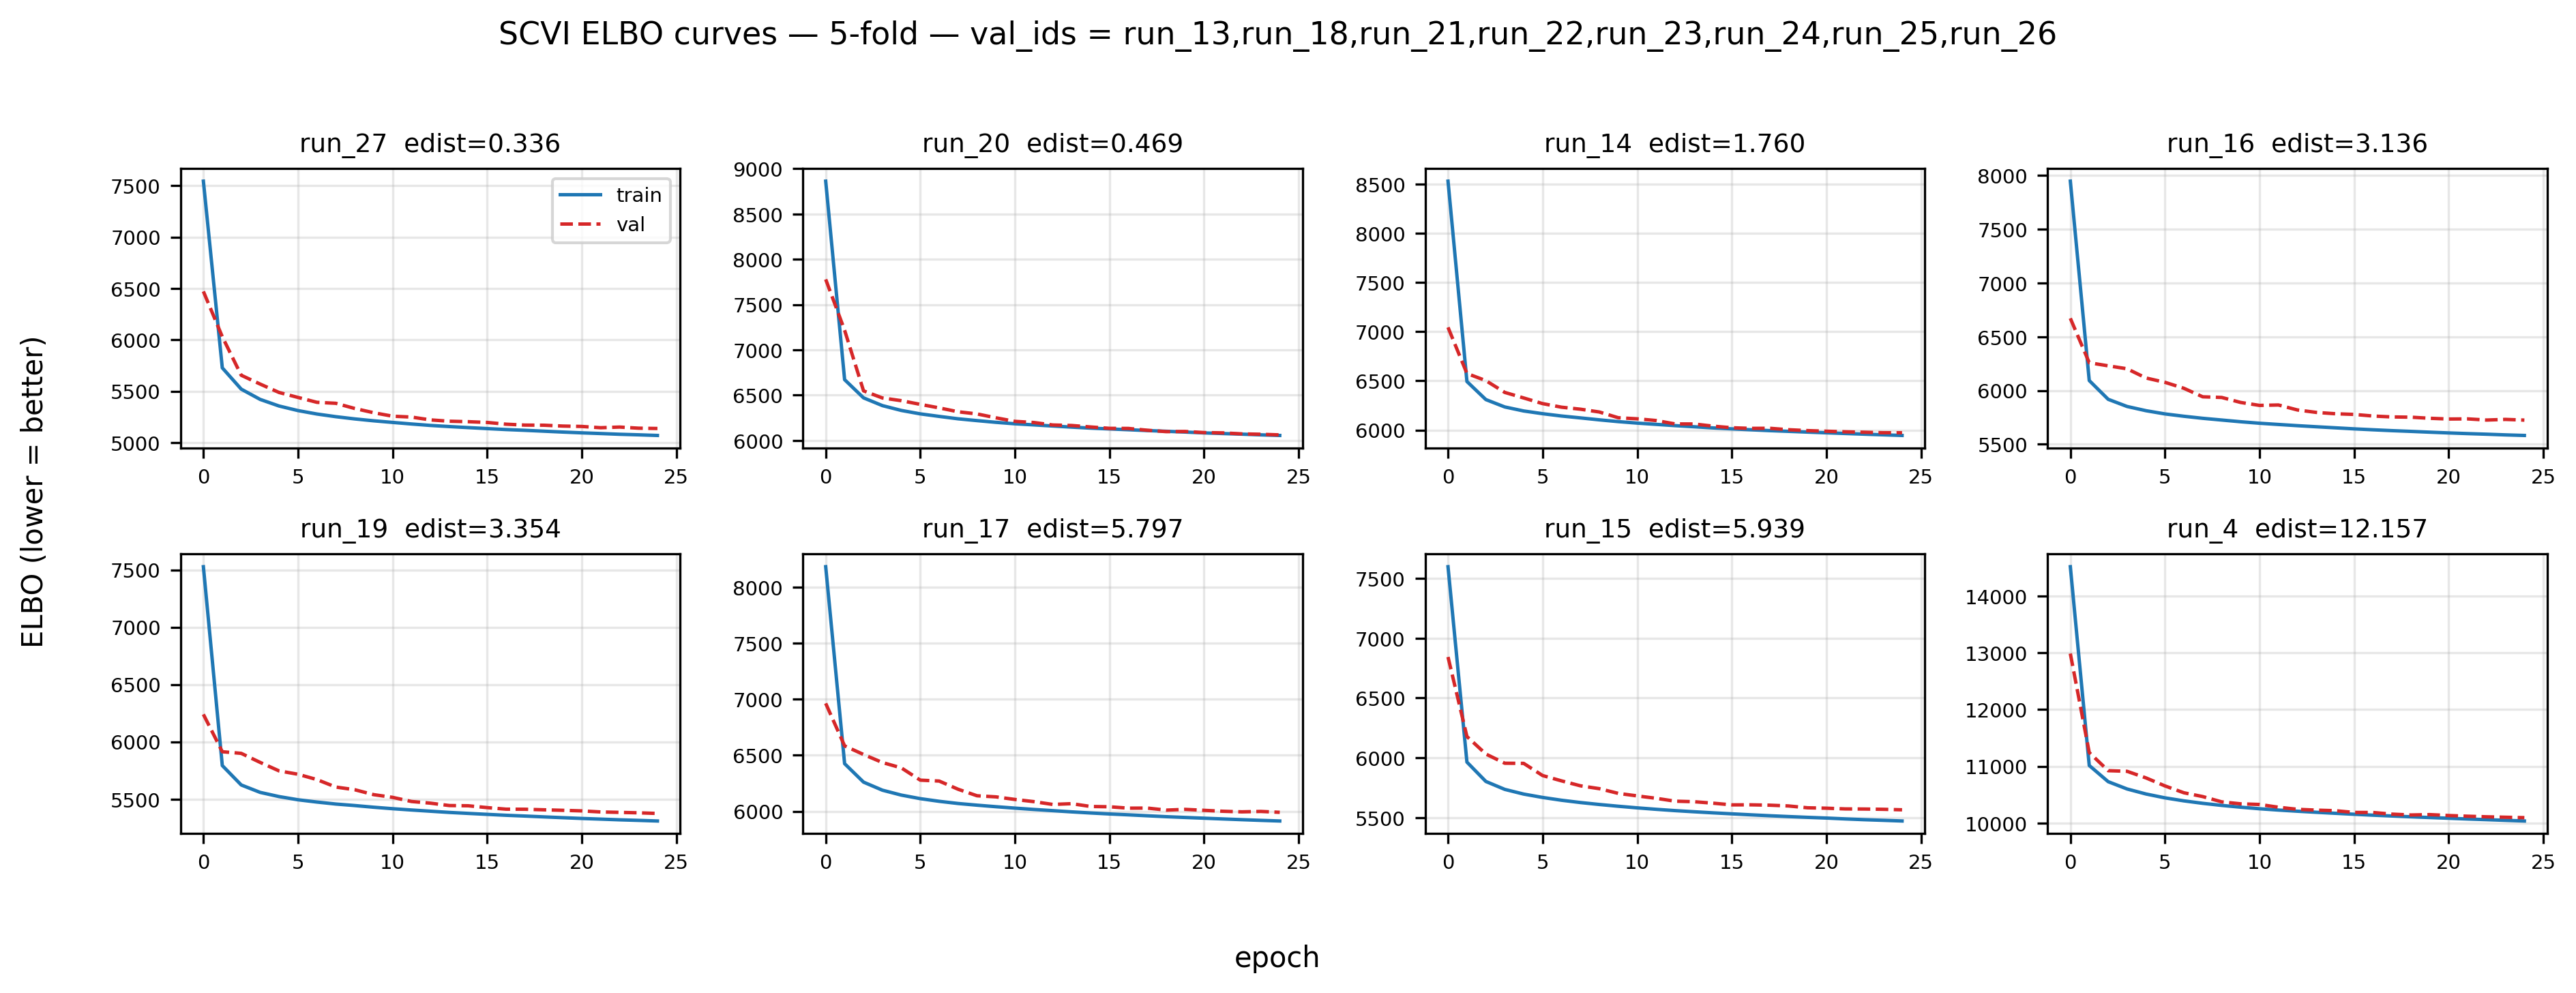

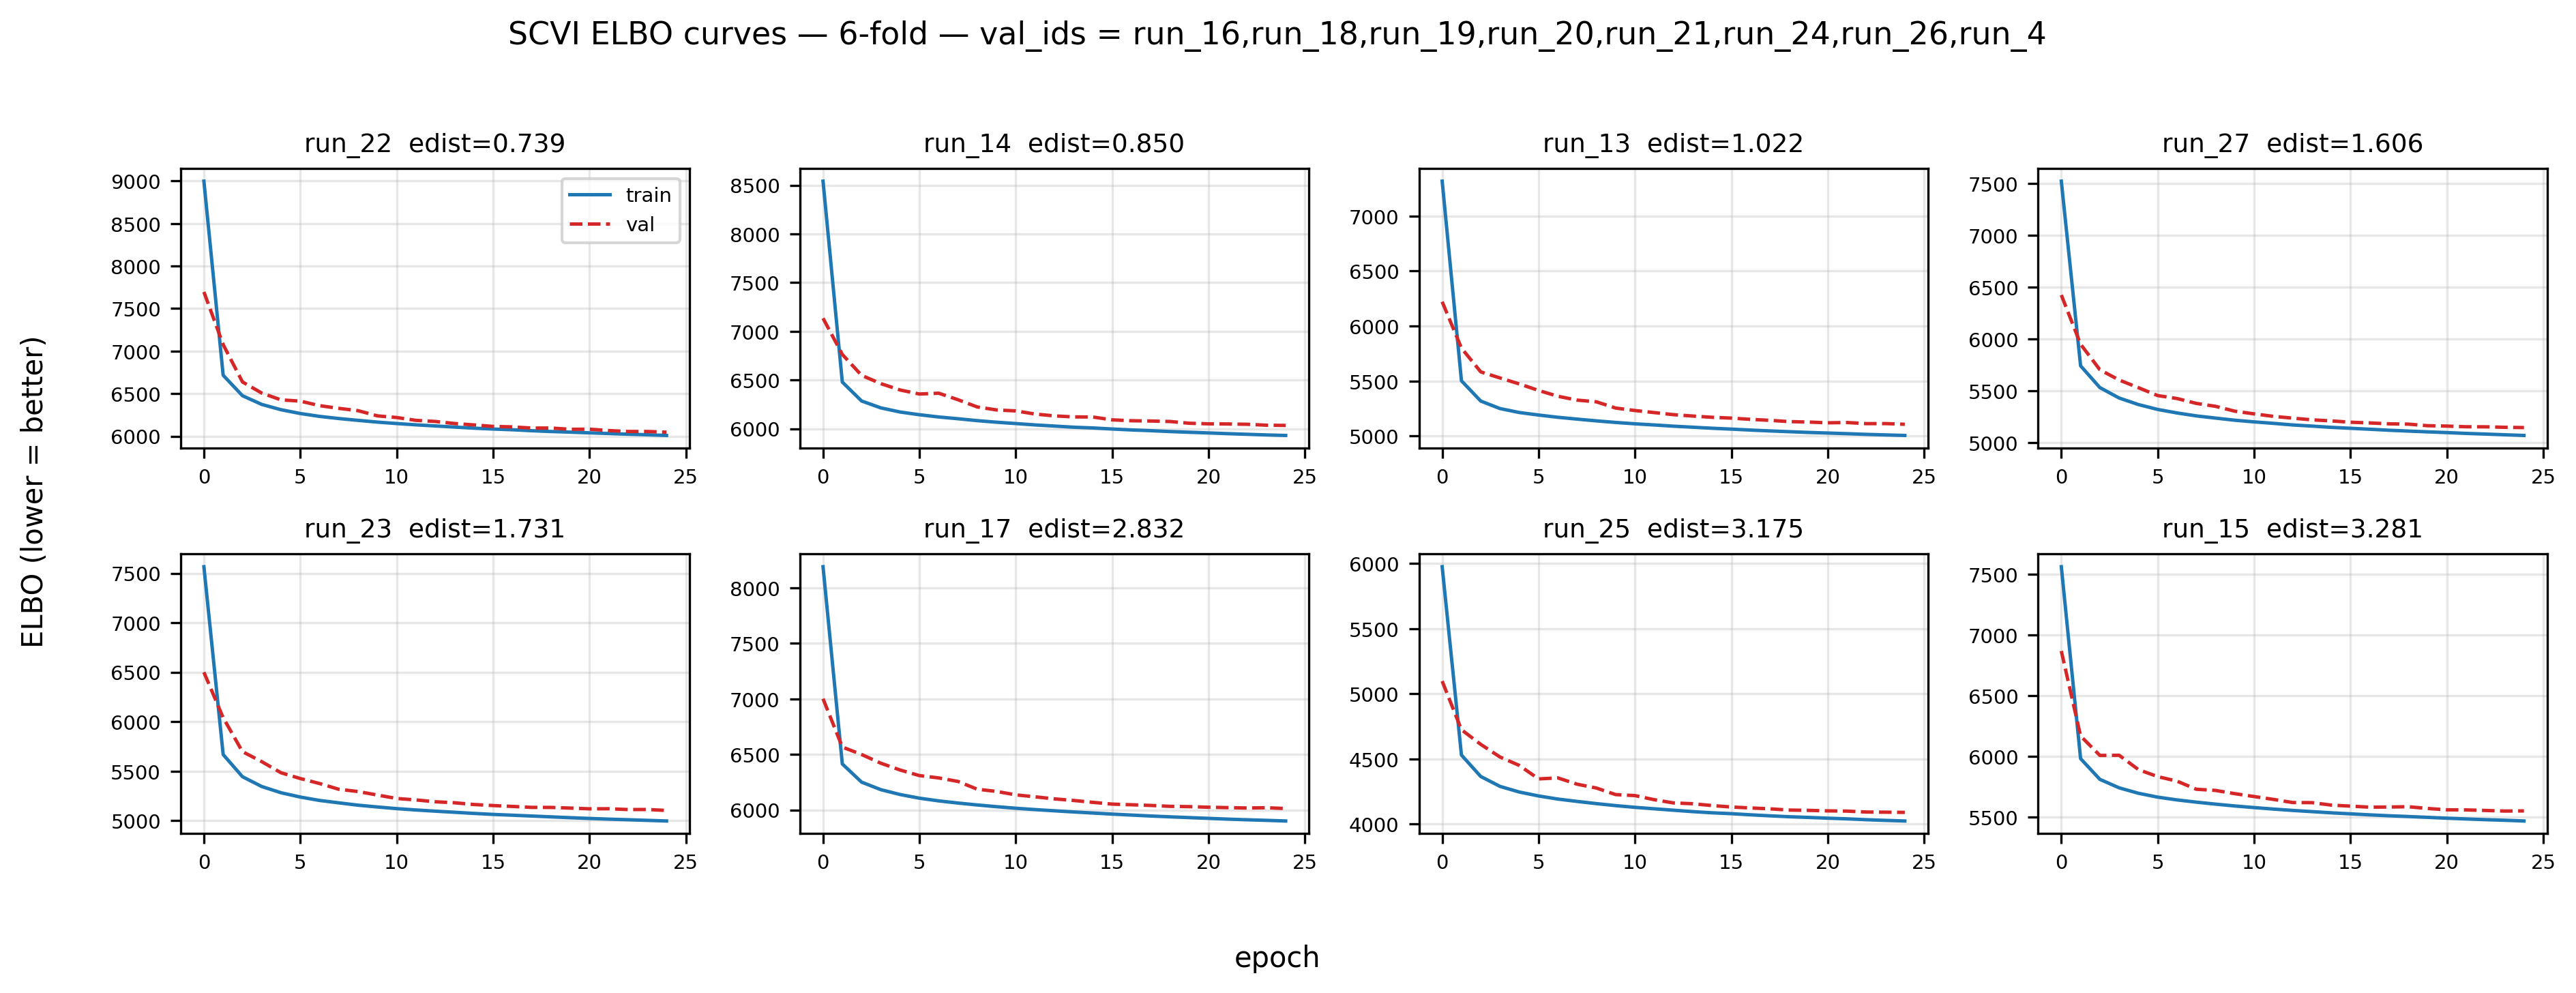

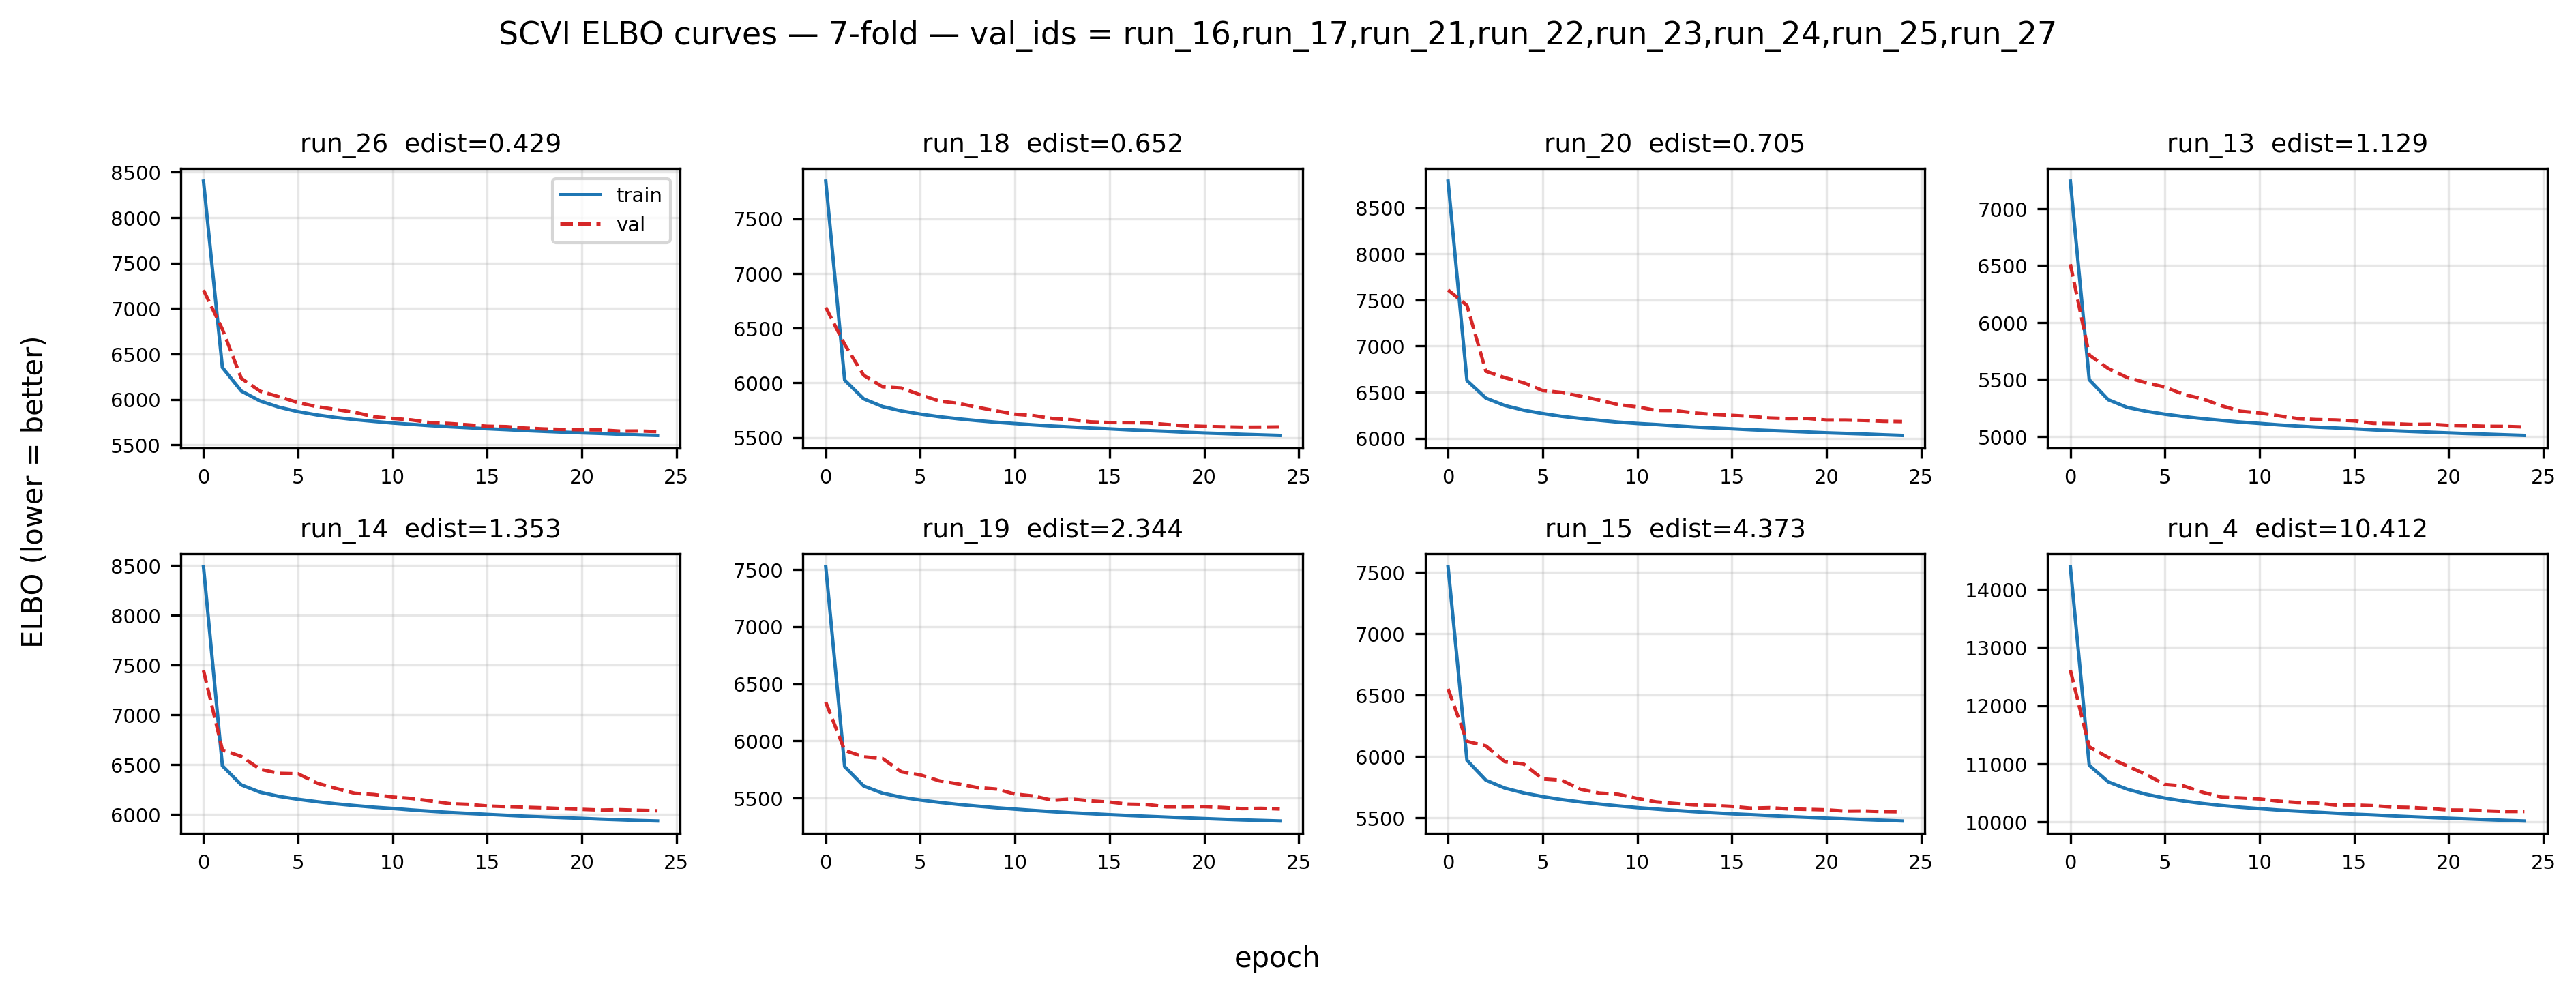

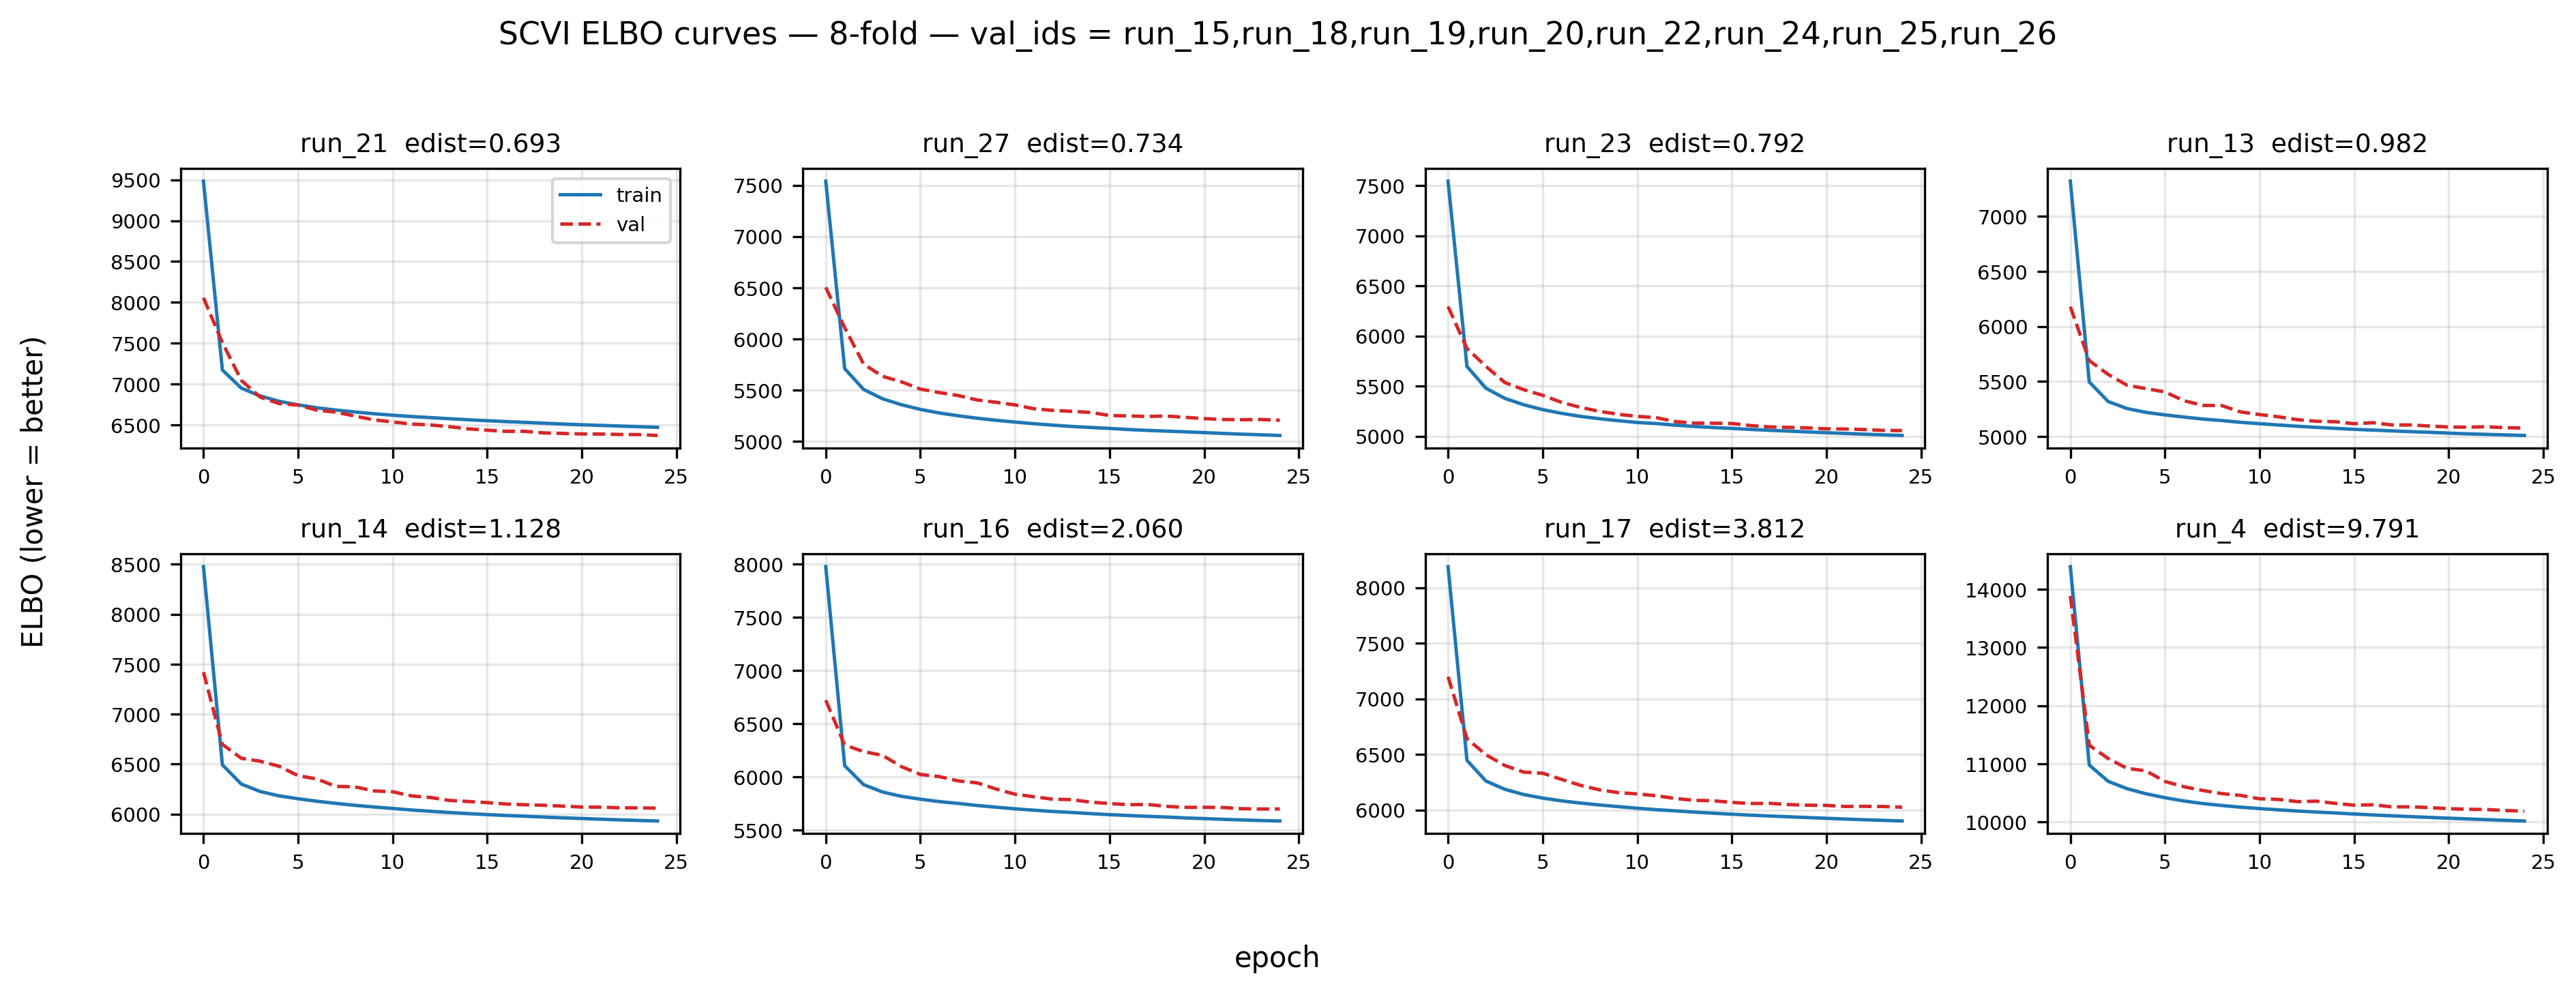

In [3]:
for fold, sub in df.groupby('fold', sort=True):
    sub = sub.sort_values('edist_train_val').reset_index(drop=True)
    n = len(sub)
    n_cols = 4
    n_rows = int(np.ceil(n / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.2 * n_cols, 2.4 * n_rows),
        dpi=FIG_DPI, sharex=False, sharey=False,
    )
    axes = np.atleast_2d(axes).reshape(n_rows, n_cols)

    for ax in axes.ravel():
        ax.set_visible(False)

    missing = []
    for i, row in sub.iterrows():
        ax = axes.ravel()[i]
        ax.set_visible(True)
        run_id = row['run_id']
        edist = row['edist_train_val']
        hist_path = SCVI_OUT_DIR / fold / run_id / 'training_history.csv'
        if not hist_path.exists():
            ax.text(0.5, 0.5, 'no training_history.csv\n(re-run compute script)',
                    ha='center', va='center', fontsize=8, transform=ax.transAxes)
            ax.set_title(f'{run_id}  edist={edist:.3f}', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
            missing.append(run_id)
            continue
        h = pd.read_csv(hist_path, index_col='epoch')
        ax.plot(h.index, h['train_loss'], color='C0', linewidth=1.2, label='train')
        ax.plot(h.index, h['val_loss'], color='C3', linewidth=1.2,
                linestyle='--', label='val')
        ax.set_title(f'{run_id}  edist={edist:.3f}', fontsize=9)
        ax.tick_params(labelsize=7)
        ax.grid(alpha=0.3)
        if i == 0:
            ax.legend(fontsize=7, loc='upper right')

    fig.suptitle(
        f'SCVI ELBO curves — {fold} — val_ids = {sub["val_ids"].iloc[0]}',
        fontsize=11,
    )
    fig.supxlabel('epoch', fontsize=10)
    fig.supylabel('ELBO (lower = better)', fontsize=10)
    fig.tight_layout(rect=[0.02, 0.02, 1, 0.96])
    if missing:
        print(f'  ({len(missing)} runs missing training_history.csv: {missing})')
    plt.show()
    plt.close(fig)

In [4]:
df[['fold', 'run_id', 'val_ids', 'edist_train_val', 'lmi', 'n_val_cells']]

,fold,run_id,val_ids,edist_train_val,lmi,n_val_cells
0,1-fold,run_14,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",0.7961,2.035872,80000
1,1-fold,run_26,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.1029,1.974775,80000
2,1-fold,run_20,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.2324,1.996421,80000
3,1-fold,run_22,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.2638,1.965257,80000
4,1-fold,run_21,"run_13,run_15,run_16,run_17,run_18,run_19,run_...",2.4979,2.005583,80000
...,...,...,...,...,...,...
59,8-fold,run_13,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",0.9821,1.553028,80000
60,8-fold,run_14,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",1.1279,1.554950,80000
61,8-fold,run_16,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",2.0598,1.574077,80000
62,8-fold,run_17,"run_15,run_18,run_19,run_20,run_22,run_24,run_...",3.8119,1.589389,80000
